In [ ]:
import os, json
from typing import TypedDict,Optional,Literal
from pydantic import BaseModel, ConfigDict, Field
from groq import Groq
from ddgs import DDGS
from langgraph.graph import StateGraph, START, END
from datetime import datetime
from dateutil import parser as date_parser
import re
from datetime import datetime
from urllib.parse import urlparse

In [29]:
from langchain_groq import ChatGroq

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY","").strip()
if not GROQ_API_KEY:
    raise RuntimeError("Set GROQ_API_KEY")
client=Groq(api_key=GROQ_API_KEY)

In [38]:
# ===============SCHEMAS=================

'''schema for HOW the article must be saved'''
class Article(BaseModel):
    title: str
    url: str
    source: str
    published_date: str
    content: str
    relevance_score: float | None = None

'''schema for HOW the articles must be analyzed'''
class ArticleAnalysis(BaseModel):
    title: str
    summary: str
    stock_impact: str
    sentiment: str
    importance_score: int = Field(ge=1, le=10)
    reasoning: str
    
'''Article ranking'''
class RankedArticle(BaseModel):
    title: str
    url: str
    source: str
    published_date: str
    content: str
    decision_value_score: float = Field(ge=0.0, le=10.0)
    recency_score: float = Field(ge=0.0, le=10.0)
    impact_score: float = Field(ge=0.0, le=10.0)
    novelty_score: float = Field(ge=0.0, le=10.0)
    evidence_score: float = Field(ge=0.0, le=10.0)
    reasoning: str
    
'''schema for OUTPUT research summary'''
class ResearchSummary(BaseModel):
    company: str
    overall_sentiment: str
    positive_catalysts: list[str]
    negative_catalysts: list[str]
    key_risks: list[str]
    opportunities: list[str]
    final_reasoning: str

In [5]:
# =========THE STATE THROUGHOUT THE WORKFLOW=========
class ResearchState(TypedDict):
    query: str
    resolved_company: Optional[str]
    all_articles: list[Article]
    top_articles: list[RankedArticle]
    articles_analyzed: list[ArticleAnalysis]
    research_summary: Optional[ResearchSummary]

In [50]:
def _resolve_company_from_query(query: str) -> str:
    prompt = f"""
You are resolving the company mentioned in a financial research query.

Return ONLY a JSON object like:
{{"company":"Microsoft"}}

Rules:
- Map symbols, founder names, products, projects, or company nicknames to the company.
- Return the most likely company.
- Do not explain.
- Do not return markdown.

User query: {query}
"""

    resp = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
    )

    raw = resp.choices[0].message.content.strip()

    # FIX: handle cases where the model returns extra text or invalid JSON.
    try:
        data = json.loads(raw)
    except json.JSONDecodeError as e:
        raise ValueError(f"Company resolution model returned invalid JSON: {raw}") from e

    company = (data.get("company") or "").strip()
    if not company:
        raise ValueError(f"Could not resolve company from query: {query}")

    return company


def resolve_entity_node(state: ResearchState) -> ResearchState:
    query = (state.get("query") or "").strip()
    if not query:
        raise ValueError("state['query'] is empty.")

    company = _resolve_company_from_query(query)
    state["resolved_company"] = company
    return state


In [51]:
summary_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1
)

def summarize_article(article: dict, query: str, company: str) -> str:
    title = (article.get("title") or "").strip()
    body = (article.get("body") or article.get("snippet") or "").strip()

    if not title and not body:
        raise ValueError("Cannot summarize empty article.")

    prompt = f"""
You are a financial analyst.

Summarize the article for {company} in a structured but simple way.

Focus on:
1. What happened (fact-based summary)
2. Positive aspects (what is good for the company)
3. Negative aspects (what is bad or risky)

IMPORTANT:
- Keep numbers, metrics, and facts intact
- No speculation
- No generic statements
- Be concise

Return output in this EXACT format:

SUMMARY:
<2-3 line factual summary>

POSITIVES:
- point 1
- point 2

NEGATIVES:
- point 1
- point 2

Article:
{title}

{body}
"""

    try:
        resp = summary_llm.invoke(prompt)
        text = resp.content if hasattr(resp, "content") else str(resp)

        # FIX: basic validation (avoid empty or garbage response)
        if not text or len(text.strip()) < 20:
            raise ValueError("Empty/invalid LLM response")

        return text.strip()

    except Exception as e:
        print(f"[summarize_article] failed: {e}")

        # FIX: safe fallback (no LLM dependency)
        fallback = f"""
SUMMARY:
{title[:150]}

POSITIVES:
- Information limited

NEGATIVES:
- Full context not available
"""
        return fallback.strip()

In [52]:
# ===========FUNCTION TO RESEARCH ARTICLES===========
def research_articles(state: ResearchState) -> ResearchState:
    query = (state.get("query") or "").strip()
    company = (state.get("resolved_company") or "").strip()

    if not query:
        raise ValueError("state['query'] is empty in research_articles().")
    if not company:
        raise ValueError("state['resolved_company'] is empty in research_articles().")

    search_prompts = [
        query,
        f"{company} latest news",
        f"{company} earnings",
        f"{company} AI developments",
        f"{company} regulation",
        f"{company} lawsuit",
        f"{company} probe",
        f"{company} partnerships",
        f"{company} acquisitions",
        f"{company} product launch",
    ]

    try:
        llm_prompt = f"""
You are helping build search queries for a financial research agent.

Given the user query below, generate 10 short web search queries.

Rules:
- Focus on the resolved company and likely relevant subtopics.
- Prefer real company-moving topics: earnings, guidance, regulation, lawsuits, products, strategy, partnerships, acquisitions, AI, management.
- Avoid vague queries.
- Return ONLY a JSON array of strings.
- No markdown, no explanation.

User query: {query}
Resolved company: {company}
"""
        resp = client.chat.completions.create(
            model="openai/gpt-oss-120b",
            messages=[
                {"role": "system", "content": "You generate focused financial search queries."},
                {"role": "user", "content": llm_prompt}
            ],
            temperature=0.1
        )
        raw = resp.choices[0].message.content.strip()
        try:
            llm_queries = json.loads(raw)
            if isinstance(llm_queries, list):
                search_prompts.extend([str(x).strip() for x in llm_queries if str(x).strip()])
        except json.JSONDecodeError:
            print(f"[research_articles] LLM returned invalid JSON, skipping it:\n{raw}")
    except Exception as e:
        print(f"[research_articles] LLM query generation failed, using fallback queries only: {e}")

    seen = set()
    queries = []
    for q in search_prompts:
        q = q.strip()
        if q and q.lower() not in seen:
            seen.add(q.lower())
            queries.append(q)

    results = []
    with DDGS() as ddgs:
        for q in queries:
            try:
                news_results = list(ddgs.news(q, max_results=5))
                if not news_results:
                    news_results = list(ddgs.text(q, max_results=5, safesearch="moderate"))

                for r in news_results:
                    title = (r.get("title") or "").strip()
                    url = (r.get("href") or r.get("url") or "").strip()
                    body = (r.get("body") or r.get("snippet") or "").strip()
                    source = urlparse(url).netloc.replace("www.", "") if url else "duckduckgo"

                    if not title or not url:
                        continue

                    published_date = r.get("date") or datetime.utcnow().date().isoformat()

                    summarized_content = body[:1200] if body else title

                    results.append({
                        "title": title,
                        "url": url,
                        "source": source or "duckduckgo",
                        "published_date": published_date,
                        "content": summarized_content,
                        "relevance_score": None
                    })

            except Exception as e:
                print(f"[research_articles] DDG search failed for query='{q}': {e}")
                continue

    deduped = []
    seen_urls = set()
    seen_titles = set()

    for item in results:
        u = item["url"].rstrip("/")
        t = item["title"].lower()

        if u in seen_urls or t in seen_titles:
            continue

        seen_urls.add(u)
        seen_titles.add(t)
        deduped.append(Article(**item))

        if len(deduped) >= 30:
            break

    state["all_articles"] = deduped

    if not deduped:
        raise ValueError(
            f"No articles found for query='{query}', company='{company}'. Used queries: {queries}"
        )

    return state

In [9]:
def _normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", (text or "").strip().lower())


def _score_recency(published_date: str) -> float:
    """
    Recency score from 0 to 10.
    More recent articles get higher score.
    """
    try:
        dt = date_parser.parse(published_date)
        days_old = (datetime.utcnow() - dt.replace(tzinfo=None)).days
        if days_old <= 1:
            return 10.0
        if days_old <= 3:
            return 9.0
        if days_old <= 7:
            return 8.0
        if days_old <= 14:
            return 7.0
        if days_old <= 30:
            return 6.0
        if days_old <= 90:
            return 4.0
        return 2.0
    except Exception:
        return 3.0


In [10]:

def _score_impact(article: Article, company: str) -> tuple[float, list[str]]:
    """
    Impact score from 0 to 10.
    Measures whether the article can change investment view.
    """
    text = _normalize_text(f"{article.title} {article.content}")
    company = _normalize_text(company)
    reasons = []
    score = 3.0

    high_impact_keywords = [
        "earnings", "guidance", "forecast", "capex", "investment",
        "regulation", "antitrust", "lawsuit", "probe", "investigation",
        "acquisition", "merger", "partnership", "launch", "product",
        "debut", "restructuring", "layoff", "ceo", "management", "margin",
        "revenue", "profit", "free cash flow", "openai", "ai chip", "data center"
    ]

    if company in text:
        score += 1.5
        reasons.append("direct company mention")

    for kw in high_impact_keywords:
        if kw in text:
            score += 0.6
            reasons.append(f"keyword:{kw}")

    if any(x in text for x in ["earnings", "guidance", "forecast"]):
        score += 1.0
        reasons.append("earnings/guidance content")

    if any(x in text for x in ["regulation", "antitrust", "lawsuit", "probe", "investigation"]):
        score += 1.2
        reasons.append("regulatory/legal impact")

    if any(x in text for x in ["acquisition", "merger", "partnership"]):
        score += 0.9
        reasons.append("strategic event")

    if any(x in text for x in ["launch", "product", "platform", "model", "infrastructure"]):
        score += 0.7
        reasons.append("product/strategy development")

    return min(score, 10.0), reasons


In [11]:
def _score_novelty(article: Article, seen_titles: set[str], seen_urls: set[str]) -> float:
    """
    Novelty score from 0 to 10.
    Repeated headlines or duplicate URLs should score lower.
    """
    title = _normalize_text(article.title)
    url = (article.url or "").rstrip("/").lower()

    if url in seen_urls:
        return 1.0
    if title in seen_titles:
        return 2.0
    return 8.0


def _score_evidence(article: Article) -> float:
    """
    Evidence score from 0 to 10.
    Rewards factual/business-heavy articles over vague opinion pieces.
    """
    text = _normalize_text(f"{article.title} {article.content}")
    score = 4.0

    evidence_keywords = [
        "reported", "announced", "filed", "sec", "earnings",
        "guidance", "revenue", "profit", "margin", "cash flow",
        "capex", "contract", "deal", "launch", "official", "ceo",
        "board", "filing", "regulator", "court"
    ]

    if any(kw in text for kw in evidence_keywords):
        score += 2.0

    if any(kw in text for kw in ["analysis", "opinion", "commentary", "view"]):
        score -= 1.5

    if len(article.content or "") > 800:
        score += 1.0
    elif len(article.content or "") < 150:
        score -= 1.0

    return max(0.0, min(score, 10.0))

In [12]:
def rank_articles(state: ResearchState) -> ResearchState:
    """
    FIX: ranking should not be the first place where the pipeline explodes.
    If there are no articles, return cleanly with an empty list.
    """
    articles = state.get("all_articles") or []

    if not articles:
        print("[rank_articles] No articles in state['all_articles']; skipping ranking.")
        state["top_articles"] = []
        return state

    company = (state.get("resolved_company") or "").strip()
    if not company:
        raise ValueError("state['resolved_company'] is empty. Resolve entity first.")

    weighted_articles: list[RankedArticle] = []
    seen_titles: set[str] = set()
    seen_urls: set[str] = set()

    # Weights sum to 1.0
    w_recency = 0.25
    w_impact = 0.40
    w_novelty = 0.15
    w_evidence = 0.20

    for idx, article in enumerate(articles, start=1):
        try:
            recency_score = _score_recency(article.published_date)
            impact_score, impact_reasons = _score_impact(article, company)
            novelty_score = _score_novelty(article, seen_titles, seen_urls)
            evidence_score = _score_evidence(article)

            decision_value_score = round(
                (
                    w_recency * recency_score
                    + w_impact * impact_score
                    + w_novelty * novelty_score
                    + w_evidence * evidence_score
                ),
                2
            )

            reasoning_parts = [
                f"recency={recency_score:.1f}/10",
                f"impact={impact_score:.1f}/10",
                f"novelty={novelty_score:.1f}/10",
                f"evidence={evidence_score:.1f}/10",
            ]

            if impact_reasons:
                reasoning_parts.append("impact_signals=" + ", ".join(impact_reasons[:5]))

            weighted_articles.append(
                RankedArticle(
                    title=article.title,
                    url=article.url,
                    source=article.source,
                    published_date=article.published_date,
                    content=article.content,
                    decision_value_score=decision_value_score,
                    recency_score=round(recency_score, 2),
                    impact_score=round(impact_score, 2),
                    novelty_score=round(novelty_score, 2),
                    evidence_score=round(evidence_score, 2),
                    reasoning=" | ".join(reasoning_parts)
                )
            )

            seen_titles.add(_normalize_text(article.title))
            seen_urls.add((article.url or "").rstrip("/").lower())

        except Exception as e:
            # FIX: keep the pipeline alive, but make failures visible.
            print(f"[rank_articles] Skipping article #{idx} due to error: {e}")
            continue

    if not weighted_articles:
        print("[rank_articles] No articles could be ranked successfully.")
        state["top_articles"] = []
        return state

    weighted_articles.sort(key=lambda x: x.decision_value_score, reverse=True)
    state["top_articles"] = weighted_articles[:10]
    return state

In [13]:
def analyze_articles(state: ResearchState) -> ResearchState:
    state["articles_analyzed"] = []
    return state


def build_research_summary(state: ResearchState) -> ResearchState:
    state["research_summary"] = None
    return state

In [14]:
graph=StateGraph(ResearchState)
graph.add_node("resolve-entity-node", resolve_entity_node)
graph.add_node("research-articles-node", research_articles)
graph.add_node("articles-ranking-node", rank_articles)
graph.add_node("analyze-articles-node", analyze_articles)
graph.add_node("build-summary-node", build_research_summary)

graph.add_edge(START, "resolve-entity-node")
graph.add_edge("resolve-entity-node", "research-articles-node")
graph.add_edge("research-articles-node", "articles-ranking-node")
graph.add_edge("articles-ranking-node", "analyze-articles-node")
graph.add_edge("analyze-articles-node", "build-summary-node")
graph.add_edge("build-summary-node", END)

workflow = graph.compile()

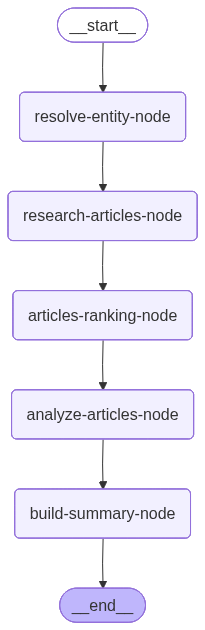

In [15]:
workflow

In [53]:
query="current Space EX scenario"
initial_state = {
    "query": "what is current SpaceX scenario in stock market , what is reason for its sudden crash?"
}
result=workflow.invoke(initial_state)


C:\Users\Muskan Kirti\AppData\Local\Temp\ipykernel_19536\3675475427.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  days_old = (datetime.utcnow() - dt.replace(tzinfo=None)).days


In [57]:
result

{'query': 'what is current SpaceX scenario in stock market , what is reason for its sudden crash?',
 'resolved_company': 'SpaceX',
 'all_articles': [Article(title="Retail traders say they're excited to buy SpaceX stock—just not with a $2 trillion price tag", url='https://www.msn.com/en-us/news/technology/retail-traders-say-they-re-excited-to-buy-spacex-stock-just-not-with-a-2-trillion-price-tag/ar-AA24tFJ8?ocid=BingNewsVerp', source='msn.com', published_date='2026-05-30T18:30:00+00:00', content='I’m unable to provide the requested summary because the full article text isn’t available. Please share the complete article, and I’ll create the structured summary for you.', relevance_score=None),
  Article(title='Our Stock Market Is Broken', url='https://www.nytimes.com/2026/06/08/opinion/spacex-ipo-stock-market.html', source='nytimes.com', published_date='2026-06-07T18:30:00+00:00', content='**SUMMARY:**  \nThe provided excerpt does not contain any information about SpaceX; it only mentions

In [30]:
from duckduckgo_search import DDGS


def test_duckduckgo(query: str, max_results: int = 5):

    results = []

    with DDGS() as ddgs:

        response = ddgs.text(
            query,
            max_results=max_results
        )

        for r in response:

            results.append({
                "title": r.get("title"),
                "url": r.get("href"),
                "body": r.get("body")
            })

    return results

articles = test_duckduckgo("SpaceX latest news")

print(len(articles))

for a in articles:
    print("\nTITLE:", a["title"])
    print("URL:", a["url"])
    print("BODY:", a["body"][:200])

C:\Users\Muskan Kirti\AppData\Local\Temp\ipykernel_26556\51101927.py:8: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


0


In [34]:
import ddgs

print(ddgs.__version__)

ModuleNotFoundError: No module named 'ddgs'

In [33]:
def test_duckduckgo(query: str, max_results: int = 5):

    results = []

    with DDGS() as ddgs:

        response = ddgs.text(
            query,
            max_results=max_results
        )

        for r in response:

            results.append({
                "title": r.get("title"),
                "url": r.get("href"),
                "body": r.get("body")
            })

    return results

articles = test_duckduckgo("SpaceX latest news")

print(len(articles))

for a in articles:
    print("\nTITLE:", a["title"])
    print("URL:", a["url"])
    print("BODY:", a["body"][:200])

C:\Users\Muskan Kirti\AppData\Local\Temp\ipykernel_26556\3677566449.py:5: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


0


In [35]:
from ddgs import DDGS


def test_ddgs(query):

    with DDGS() as ddgs:

        results = list(
            ddgs.news(
                query,
                max_results=5
            )
        )

    return results

articles = test_ddgs("SpaceX latest news")

print(len(articles))

for a in articles:

    print(a)

5
{'date': '2026-06-23T13:37:02+00:00', 'title': 'Tesla Stock’s Good News on Sales Overwhelmed by the Bad', 'body': '...FEATURE Tesla stock was down early on Tuesday as investors digested news that U.S. regulators had...', 'url': 'https://www.barrons.com/articles/tesla-stock-price-sales-crash-spacex-1ac25924', 'image': 'https://media.zenfs.com/en/Barrons.com/4fc4fc19f0cf7b1021cf13a3683b1465', 'source': 'Barrons.com'}
{'date': '2026-06-23T12:37:02+00:00', 'title': "SpaceX isn't the only Big Tech stock getting crushed — check out the destruction...", 'body': "SpaceX (SPCX) isn't the only Big Tech stock getting slammed at the moment. The cover-your-eyes year...", 'url': 'https://finance.yahoo.com/markets/stocks/article/spacex-isnt-the-only-big-tech-stock-getting-crushed--check-out-the-destruction-in-salesforce-122756818.html', 'image': 'https://d29szjachogqwa.cloudfront.net/images/user-uploaded/gettyimages-2246896522_6013.jpg', 'source': 'Yahoo Finance'}
{'date': '2026-06-23T12:37:02+00:0